# **Simulation methods**  
## This notebook presents the 3 simulations methods use for the simulation of the glacier's bedrock.  
## The 3 methods applied are :  
* Multiple-points statistics with the DeeSse algorithm implemented in the Geone package  
* Sequential gaussian simulation like with the Gaussian Random Field approach implemented in the Geone package  
* Kriging estimation

## **input** :
A pickle file that contain the following data in a list in this order:  
* The true value of the croped zone (for synthetic test) or a nan array for the real case -> numpy.array (nx,ny)
* The position of the cropped zone in the grid or the grid size for the real case -> [nx_min, nx_max, ny_min, ny_max]  
* The hard data in pandas dataFrame
* The TI -> numpy.array (nx,ny)
* The list of the two masks, one for the cropped zone only (or the glacier extend mask for the real case), one which include the cropped zone with the TI (or the glacier extend plus the uncover bedRock) -> [mask1,mask2] 

## **output** :  
A pickle file that contain the simulations outputs values

In [1]:
#import of the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.linear_model import LinearRegression as lr 

#import from package 'geone'
from geone import img
from geone import grf
import geone.imgplot as imgplt
import geone.customcolors as ccol
import geone.deesseinterface as dsi


#read the simulation methods function file
exec(open('./functions/02_simulation_functions.py').read())
exec(open('./functions/02_kriging_functions.py').read())


%matplotlib inline
%xmode Plain

Exception reporting mode: Plain


## Import the data

In [3]:
path_data_test = 'generated_data/'
path_ti        = 'data/TI/pickle/ti_alt1_2016_2m.pickle'
simu_test_name = os.listdir(path_data_test)[0]
simu_test_name

'realisation0.pickle'

In [ ]:
#read the data (see the generated data structure file for more information)
trueMNT, position, hd_df, ti, mask = read_data(path_data_test, simu_test_name)

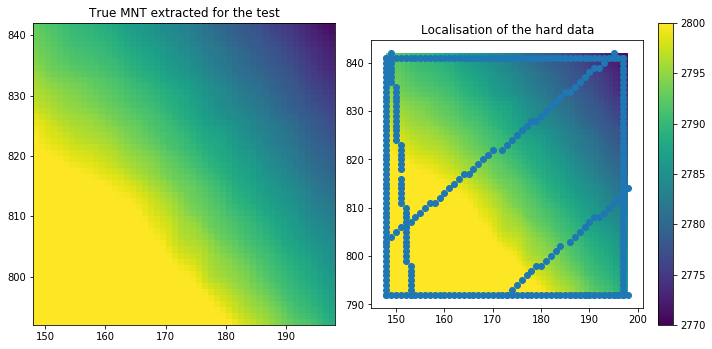

In [4]:
fig = plt.subplots(1,2,figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(trueMNT,extent=position,vmin=2770,vmax=2800)
plt.title('True MNT extracted for the test')
plt.tight_layout()

plt.subplot(1,2,2)
plt.imshow(trueMNT, extent=position,vmin=2770,vmax=2800)
plt.title('Localisation of the hard data')
plt.colorbar(fraction=0.05)
plt.scatter(hd_df['cell_x'],hd_df['cell_y'])

plt.tight_layout()


plt.show()

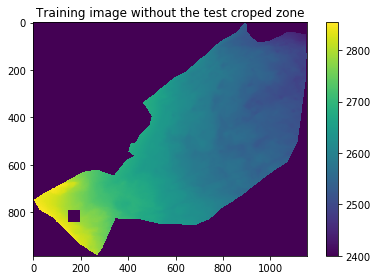

In [5]:
plt.imshow(ti,vmin=2400)
plt.title('Training image without the test croped zone')
plt.colorbar(fraction=0.05)
plt.tight_layout()

## MPS DeeSse

### PointSet and TI as conditionning data
The first MPS simulation take the TI and the pointSet as conditionning data.
The simulation use 2 pyramide levels.  
The default parameters for DeeSse are n=12, t=0.05, f=0.50.

********************************************************************************
DEESSE VERSION 3.2 / BUILD NUMBER 20200213
********************************************************************************
DONE


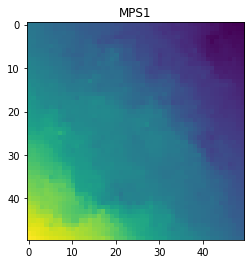

In [6]:
mask_ti = mask[1]
hd_pts  = create_hd(hd_df)
ti_img  = create_ti(ti)
simu    = deeSse_run_ti(ti_img, mask_ti, hd_pts)
extra   = extract_simu_zone(simu,position)
plt.imshow(extra[0])
plt.title('MPS1')
plt.show()

### PointSet as conditionning data
The second MPS simulation only take the pointSet as conditionning data.  
The simulation use 2 pyramide levels.  
The default parameters for DeeSse are n=12, t=0.05, f=0.50.

********************************************************************************
DEESSE VERSION 3.2 / BUILD NUMBER 20200213
********************************************************************************
DONE


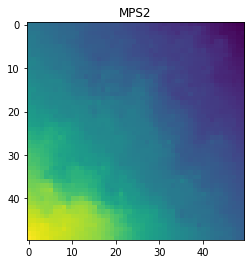

In [7]:
mask_ti = mask[0]
hd_pts  = create_hd(hd_df)
ti_img  = create_ti(ti)
simu    = deeSse_run_zone(ti_img, mask_ti, hd_pts)
extra   = extract_simu_zone(simu,position)
plt.imshow(extra[0])
plt.title('MPS2')
plt.show()

## GRF

### Experimental variogram
The first step is to compute the experimental variogram based on the full TI in order to chosse the variogram model to use for the simulation and the kriging.

In [3]:
path_ti_img = 'data/TI/pickle/ti_alt1_2016_2m.pickle'
with open(path_ti_img,'rb') as file:
    ti_full = pickle.load(file)

In [6]:
ti_pts = img.imageToPointSet(ti_full)
ti_pts = pointSetToPandas(ti_pts)
ti_pts = ti_pts.sample(frac=0.05)
ti_pts = ti_pts.dropna()
ti_pts.head()

,X,Y,Z,alt
660617,585461.0,129673.0,0.5,2512.907
888970,584787.0,130069.0,0.5,2582.216
477891,584989.0,129357.0,0.5,2555.455
1061137,584931.0,130367.0,0.5,2545.648
268379,584075.0,128995.0,0.5,2690.741


We remove the trend of the data.

In [7]:
X = [[x,y] for x,y in zip(ti_pts['X'],ti_pts['Y'])]
X = np.array(X)
Y = np.array(ti_pts['alt'])
X,Y

(array([[585461., 129673.],
        [584787., 130069.],
        [584989., 129357.],
        ...,
        [584459., 129859.],
        [584945., 129393.],
        [584493., 129265.]]),
 array([2512.907, 2582.216, 2555.455, ..., 2626.046, 2552.268, 2604.771]))

In [8]:
regLinear = lr().fit(X,Y)
regLinear.score(X,Y), regLinear.coef_

(0.9531709446219347, array([-0.1439642 , -0.01590338]))

In [9]:
trend_alt = regLinear.predict(X)
alt       = ti_pts['alt']-trend_alt

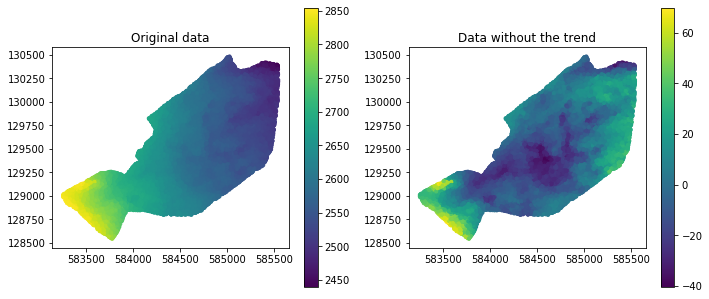

In [10]:
fig  = plt.subplots(1,2,figsize=(10,10))

plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1],s=10,c=ti_pts['alt'])
plt.title('Original data')
plt.axis('scaled')
plt.colorbar(shrink=0.4)

plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1],s=10,c=alt)
plt.title('Data without the trend')
plt.axis('scaled')
plt.colorbar(shrink=0.4)

plt.tight_layout()

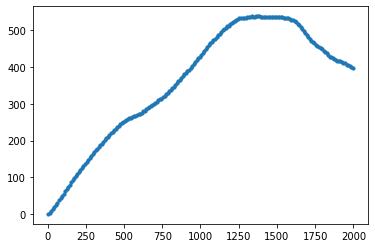

In [12]:
#Variogram cloud
hc,gc = cloud(X[:,0],X[:,1],alt)
#Experimental variogram
he, ge = experimental(hc,gc,10,200)
plt.scatter(he,ge,s=10)
plt.show()

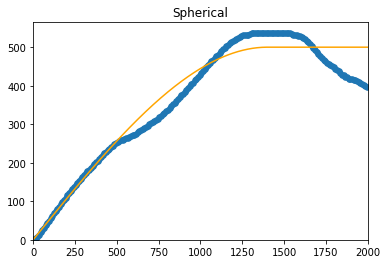

In [16]:
#Fit the experimental model
lag, nlag      = 10, 200
sillE, rangeE  = 500,  1400
x   = np.linspace(0, nlag * lag, 1000)
y_1 = spherical(x, sillE, rangeE)
y_2 = nugget(x, 0)
y   = y_1 + y_2
plt.scatter(he, ge, s=30)
plt.xlim(xmin=0, xmax=lag * nlag)
plt.ylim(ymin=0)
plt.title('Spherical')
plt.plot(x, y,color='orange')
plt.show()

We now run the GRF simulations.

In [13]:
#Set the model:
cov_model = gcm.CovModel2D(elem=[
    ('spherical', {'w':500., 'r':[1400]}), # elementary contribution
                       ], alpha=0, name='model-2D test')

In [14]:
#Set the function:
cov_fun = cov_model.func()
vario_fun = cov_model.vario_func()

In [16]:
#Prepare the data and the grid:
X,Y = create_hd_grf(hd_df,position)
dimension, spacing, origin = create_grid(position)

In [18]:
extensionMin =  [grf.extension_min(r, n, s) for r, n, s in zip(cov_model.rxy(), dimension, spacing)]
simGRF       = grf.grf2D(cov_fun, dimension, spacing, origin, x=X, v=Y, 
                   extensionMin=extensionMin, nreal=int(2))

GRF2D: Preliminary computation...
GRF2D: Computing circulant embedding...
GRF2D: Embedding dimension: 4096 x 4096
GRF2D: Computing FFT of circulant matrix...
GRF2D: Treatment of conditioning data...
GRF2D: Computing covariance matrix (rAA) for conditioning locations...
GRF2D: Computing index in the embedding grid for non-conditioning / conditioning locations...
GRF2D: Unconditional simulation    1-   2 of    2...
GRF2D: Updating conditional simulation    1 of    2...
GRF2D: Updating conditional simulation    2 of    2...


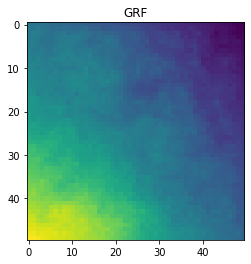

In [21]:
plt.imshow(simGRF[0])
plt.title('GRF')
plt.show()

## Kriging  
We re-used the variogram model define for the GRF

In [22]:
krige, krige_std = grf.krige2D(X, Y, cov_fun, dimension, spacing, origin, 
                                   extensionMin=extensionMin)        

KRIGE2D: Computing circulant embedding...
KRIGE2D: Embedding dimension: 4096 x 4096
KRIGE2D: Computing FFT of circulant matrix...
KRIGE2D: Computing covariance matrix (rAA) for conditioning locations...
KRIGE2D: Computing index in the embedding grid for non-conditioning / conditioning locations...
KRIGE2D: computing kriging estimates...
KRIGE2D: computing kriging standard deviation ...


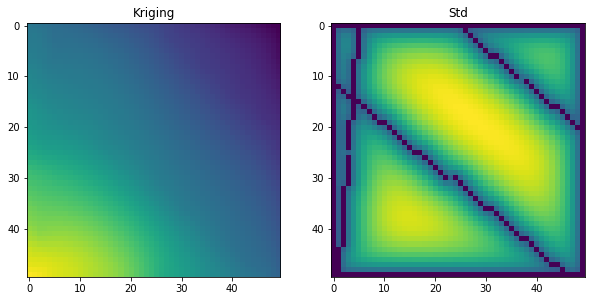

In [24]:
plt.subplots(1,2,figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(krige)
plt.title('Kriging')

plt.subplot(1,2,2)
plt.imshow(krige_std)
plt.title('Std')
plt.show()